In [2]:
import matplotlib.pyplot as plt
import hypernetx as hnx

import warnings 
warnings.simplefilter('ignore')

# Overview
This notebook presents multiple hypergraph visualization methods that focus on encoding incidence information. An incidence is simply the existence of a relationship between a hyper edge and a node. All hypergraph visualizations convey this incidence information in some way, but the visualizations in this notebook represent incidences directly as *marks*, and allow data to be encoded directly onto incidences, e.g. using a *color channel*.

The methods shown here are also adept at visualizing *ordered hypergraphs*. In an ordered hypergraph, a total order is provided for the hyper edges or nodes (or both) in addition to the hypergraph. This is provided to the drawing functions as an additional parameter named `edge_order` or `node_order` which is is simply a list of the nodes or edges.

TOC
1. Introduction
    1. Simple example
    2. Visual encodings
2. Ordered Hypergraphs
3. 

# A Simple Example
In this example we use a data generator to produce a small hypergraph based the *jean.dat* dataset available from the Stanford GraphBase at https://www-cs-faculty.stanford.edu/~knuth/sgb.html. This data gives character scene incidence information from the novel Les Miserables by Victor Hugo.

The `create_lesmis_small` and all generators in the `hypernetx.utils.toys.storylines` return a hypergraph and a `kwargs` dictionary that contains, at least, the `edge_order` appropriate for that dataset.

{'edge_order': [0, 1, 2, 3, 4, 5, 6, 7]}

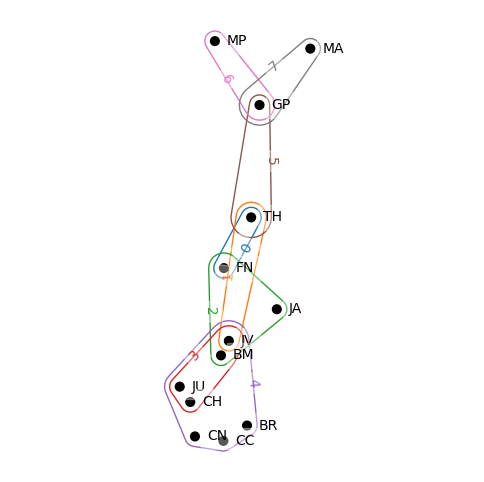

In [27]:
from hypernetx.utils.toys.storylines import create_lesmis_small

H, kwargs = create_lesmis_small()

plt.figure(figsize=(6, 6))
hnx.draw(H)

kwargs

The simplest incidence visualization available in `hypernetx` is based on [UpSet by Lex et al](https://ieeexplore.ieee.org/abstract/document/6876017/). This visualization was designed to visualize set systems in a matrix layout where each row corresponds to a set and each column corresponds to an item. These set systems are equivalent to hypergraphs if we assume hyper edges are sets and nodes are items. We diverge from the UpSet representation slightly by always placing hyper edges on the *x-axis* and hyper nodes on the *y-axis*.

To be consistent with our previous visualization design language, we made the following additional default choices:
* Hyper edges are drawn like *rubber bands* containing their nodes, and assigned a unique color, but
* [**New**] Each node-edge incidence is a filled black circle, and
* [**New**] Incidences for each node are connected by a thin black line

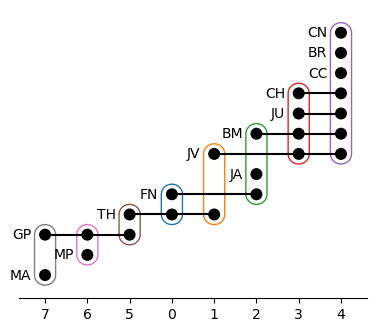

In [28]:
hnx.draw_incidence_upset(H)

## Encoding Data onto Incidences
The example below demonstrates one way to encode information onto a mark representing an incidence. Similar to other `hypernetx.draw*` methods, the `incidences_kwargs` dictionary is used to flexibly transform your data and pass it through to the underlying function that draws the circles. Like the other `*_kwargs` drawing parameters, the keys in the dictionary are valid array arguments for `matplotlib.collection.EllipseCollection`. In this case `facecolor` and `edgecolor` are useful options. The values for this dictionary can be one of:
* List-like: using the canonical incidence order (see below)
* Dict-like: mapping an incidence tuple to a value, e.g. `{(1, "JV"): "pink"}'`
* Function: taking a incidence tuple as input, e.g. `lambda i: "pink" if i == (1, "JV") else "black"`
* Constant, e.g. `"pink"`

The example below demonstrates how to set the `facecolor` of the incidences conditionally, i.e. to *black* if the node is "JV" or the edge is *2*. This is done using the list-like input, which requires iterating over the incidences in the hypergraph in canonical order, i.e. first for each edge and then for each node in that edge. To avoid having to remember the canonical order, use the equivalent dict-like or function inputs.

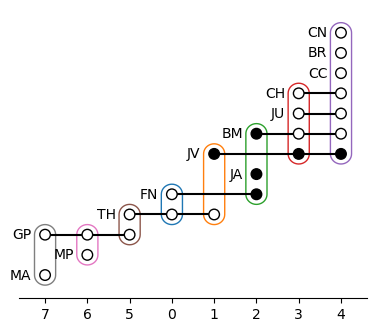

In [58]:
hnx.draw_incidence_upset(
    H,
    incidences_kwargs=dict(
        facecolor=[
            'black' if e == 2 or v == 'JV' else 'white'
            for e in H.edges
            for v in H.edges[e]
        ]
    )
)

For ease of use and compatability with other `hypernetx.draw*` methods, the `nodes_kwargs` parameter is available to be used. In this case `edgecolor` will affect the line drawn between incidences as well as the outline of the incidences themselves.

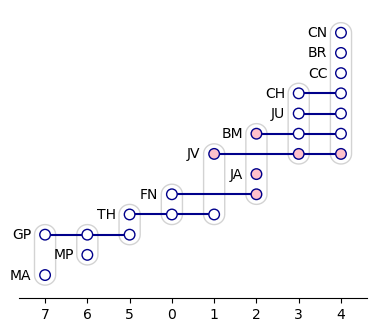

In [70]:
hnx.draw_incidence_upset(
    H,
    edges_kwargs=dict(edgecolor='lightgray'),
    nodes_kwargs=dict(edgecolor='darkblue'),
    incidences_kwargs=dict(
        facecolor=[
            'pink' if e == 2 or v == 'JV' else 'white'
            for e in H.edges
            for v in H.edges[e]
        ]
    )
)

# Ordered Hypergraphs

In the example above, you can see that the hyper edges are drawn "out of order". By default, when no `node_order` or `edge_order` is provided to the function, the drawing algorithm determines an arrangement of the hyper edges and nodes that tends to be more aesthetically pleasing than random. Specifically, we compute a spectral ordering of the bipartite representation of the hypergraph using `networkx.spectral_ordering`. When only one of `node_order` or `edge_order` is provided, the automatic ordering is still computed, but only used for the unspecified ordering. The example below shows several possible combinations of these orders.

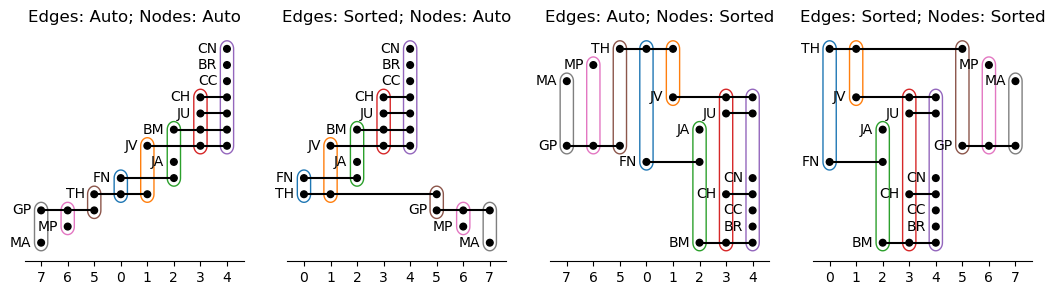

In [42]:
plt.figure(figsize=(13, 3))
i = 1
for no in (None, sorted(H.nodes)):
    for eo in (None, kwargs['edge_order']):
        hnx.draw_incidence_upset(H, edge_order=eo, node_order=no, ax=plt.subplot(1, 4, i), auto_size=False)
        plt.title(f'Edges: {"Auto" if eo is None else "Sorted"}; Nodes: {"Auto" if no is None else "Sorted"}')
        i += 1

## Advanced Temporal Visualizations
In the visualization below you might have noticed cases where the line for a node crosses an edge, but there is no circle present.

In [24]:
hnx.draw_incidence_storyline

<function hypernetx.drawing.draw_storyline.draw_incidence_storyline(H, layout=None, layout_kwargs={}, ax=None, fig=None, auto_size=True, y_cap_scale=2, y_spacing=1, node_radius=None, edge_order=None, node_order=None, node_labels=None, edge_labels=None, with_node_labels=True, with_edge_labels=True, fill_edges=False, fill_edge_alpha=-0.5, edges_kwargs={}, nodes_kwargs={}, segments_kwargs={}, edge_labels_kwargs={}, node_labels_kwargs={}, edge_labels_on_axis=True, incidences_kwargs={})>

# Visualization

## UpSet Visualization

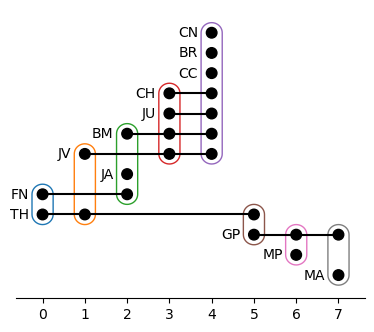

In [14]:
hnx.draw_incidence_upset(H, **kwargs)

## Advanced Visualization Parameters

### Edge order

Pass an array of edges to `edge_order` to create a layout with sorted edges

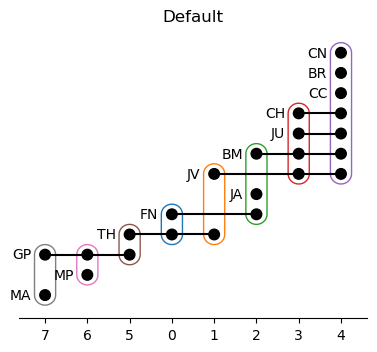

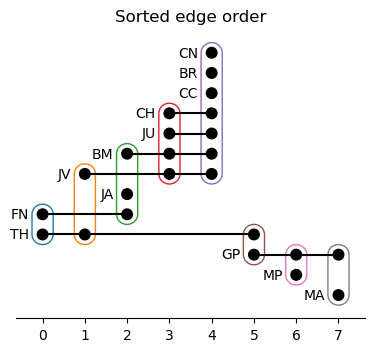

In [6]:
plt.figure()
plt.title('Default')
hnx.draw_incidence_upset(H)

plt.figure()
plt.title('Sorted edge order')
hnx.draw_incidence_upset(
    H,
    edge_order = sorted(H.edges)
)

### Label locations
Set `node_labels_on_axis` to *True* to view node labels on the vertical axis instead of beside the nodes. (The node labels are located beside the nodes by default.)

Set `edge_labels_on_axis` to *False* to see edge labels below the edges instead of on the horizontal axis.  (The edge labels are placed on the axis by default.)

Text(0, 0.5, 'Edge label not on axis')

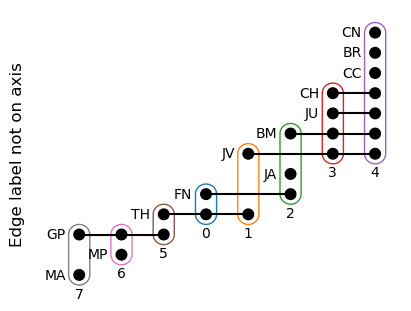

In [9]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))

# plt.subplot(2, 2, 1) 
# hnx.draw_incidence_upset(H)

# plt.title('Node label not on axis (default)')
# plt.ylabel("Edge label on axis (default)", rotation=90, fontsize=12, labelpad=20)  # 90 degrees is vertical

# plt.subplot(2, 2, 2)
# hnx.draw_incidence_upset(
#     H,
#     node_labels_on_axis=True
# )
# plt.title('Node label on axis')

# plt.subplot(2, 2, 3) 
hnx.draw_incidence_upset(
    H,
    edge_labels_on_axis=False
)
plt.ylabel("Edge label not on axis", rotation=90, fontsize=12, labelpad=20)  # 90 degrees is vertical

# plt.subplot(2, 2, 4) 
# hnx.draw_incidence_upset(
#     H,
#     node_labels_on_axis=True,
#     edge_labels_on_axis=False
# )

# plt.tight_layout()
# plt.show()